In [ ]:
# import the important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings("ignore")
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.impute import SimpleImputer
from sklearn.utils import resample

In [ ]:
# import the data set using the cood in the websit (data websit)
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# Clean target variable 'income' by removing trailing dots and stripping whitespace
y['income'] = y['income'].astype(str).str.replace('.', '', regex=False).str.strip()

# metadata
print(adult.metadata)

# variable information
print(adult.variables)

print(X.head())
print(X.info())
print(X.describe())

print(y.info())

{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [ ]:
# Identify categorical vs numeric columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("\nNumeric columns:", num_cols)
print("Categorical columns:", cat_cols)

# I'll use SimpleImputer(strategy='most_frequent') for categoricals and median for numerics to handel messing value.
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')


Numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [ ]:
# Build ColumnTransformer: numeric -> (impute -> scale), categorical -> (impute -> onehot)
# Note: sparse=False so result is a dense numpy array (SVM accepts dense arrays).
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', num_imputer), ('scaler', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imputer', cat_imputer),
                          ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
    ],
    remainder='drop',  # drop any other columns (shouldn't be any)
    sparse_threshold=0
)

In [ ]:
# # Train/test split (just for SVM)
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42, stratify=y)

# Fit preprocessor on training data and transform both train & test
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

In [ ]:
# take 15% sample from X_train_proc and y_train while keeping class balance
# Combine X and y into a single DataFrame to perform class balancing
train_df = pd.DataFrame(X_train_proc.copy())
train_df['target'] = y_train['income'].values

# Separate majority and minority classes
majority = train_df[train_df['target'] == "<=50K"]
minority = train_df[train_df['target'] == ">50K"]

# Undersample the majority class to match the minority class size
# This creates a balanced dataset (50% / 50%)
minority_count = len(minority)
majority_downsampled = resample(
    majority,
    replace=False,
    n_samples=minority_count,
    random_state=42
)

# Combine the balanced majority and minority subsets
balanced_df = pd.concat([majority_downsampled, minority])

# Shuffle the balanced dataset
balanced_df = balanced_df.sample(frac=1, random_state=42)

# Take only 15% of the balanced dataset to speed up SVM training
sample_df = balanced_df.sample(frac=0.15, random_state=42)

# Split back into X and y
X_sample = sample_df.drop("target", axis=1)
y_sample = sample_df["target"]

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params (Linear): {'C': 0.1}
Best CV score (Linear): 0.8056234718826406
model 1: 
Predicted labels: ['<=50K' '<=50K' '<=50K' ... '<=50K' '<=50K' '<=50K']
Accuracy: 0.7772469801405856

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.95      0.75      0.84     11147
        >50K       0.52      0.88      0.65      3506

    accuracy                           0.78     14653
   macro avg       0.74      0.81      0.74     14653
weighted avg       0.85      0.78      0.79     14653



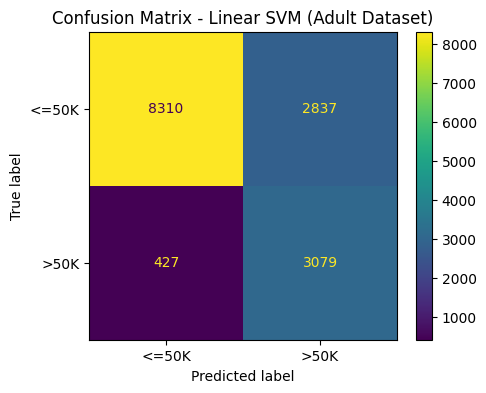

In [ ]:
# Linear SVM (model 1)
# Model building and training
param_grid_linear = {
    'C': [0.1, 1,5, 10]
}
svm_linear = SVC(kernel='linear', probability=True)

grid_linear = GridSearchCV(
   svm_linear,
    param_grid_linear,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_linear.fit(X_sample, y_sample)

print("Best params (Linear):", grid_linear.best_params_)
print("Best CV score (Linear):", grid_linear.best_score_)

print("model 1: ")
# make prediction using the best estimator from GridSearchCV
y_pred1 = grid_linear.predict(X_test_proc)
print("Predicted labels:", y_pred1)

# Evaluate the Model 1
accuracy = accuracy_score(y_test, y_pred1)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred1, target_names=['<=50K', '>50K']))


# Confusion Matrix for model 1
labels = ['<=50K', '>50K']
cm = confusion_matrix(y_test, y_pred1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax)
plt.title("Confusion Matrix - Linear SVM (Adult Dataset)")
plt.show()

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best params (RBF): {'C': 1, 'gamma': 0.1}
Best CV score: 0.814995925020375
model 2: 
Predicted labels: ['<=50K' '<=50K' '<=50K' ... '<=50K' '<=50K' '<=50K']
Accuracy: 0.7912372892922951

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.95      0.77      0.85     11147
        >50K       0.54      0.87      0.67      3506

    accuracy                           0.79     14653
   macro avg       0.74      0.82      0.76     14653
weighted avg       0.85      0.79      0.80     14653



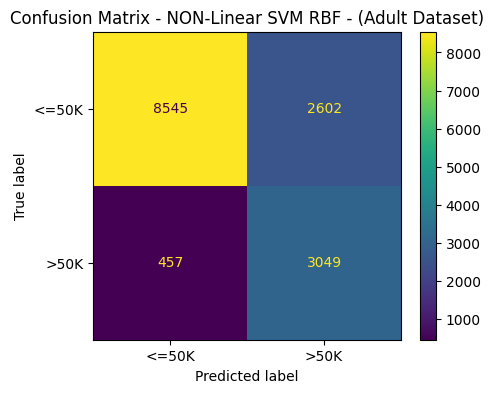

In [ ]:
# NON-Linear SVM (RBF)(model 2)
# Model building and training
param_grid_rbf = {
    'C': [1, 5, 10],
    'gamma': ['scale', 0.1, 0.01]
}

grid_rbf = GridSearchCV(
    SVC(kernel='rbf', probability=True),
    param_grid_rbf,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_rbf.fit(X_sample, y_sample)

print("Best params (RBF):", grid_rbf.best_params_)
print("Best CV score:", grid_rbf.best_score_)

print("model 2: ")
# Make Predictions for model 2
y_pred2 = grid_rbf.predict(X_test_proc)
print("Predicted labels:", y_pred2)

# Evaluate the Model 2
accuracy = accuracy_score(y_test, y_pred2)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred2, target_names= ['<=50K', '>50K']))

# Confusion Matrix for model 2
labels = ['<=50K', '>50K']
cm = confusion_matrix(y_test, y_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax)
plt.title("Confusion Matrix - NON-Linear SVM RBF - (Adult Dataset)")
plt.show()

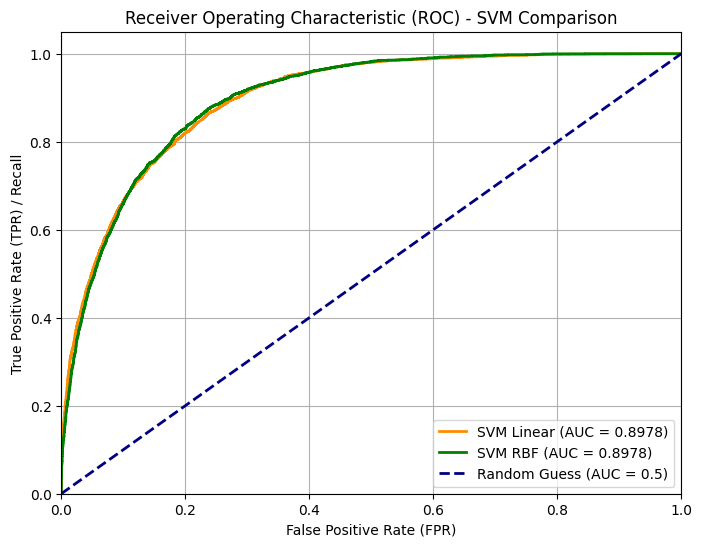

In [ ]:
#plot ROC for tow models
# Get the best estimators from GridSearchCV
best_linear = grid_linear.best_estimator_
best_rbf = grid_rbf.best_estimator_

# Ensure y_test is a 1D array for roc_curve and roc_auc_score
y_test_labels = y_test['income']

# Convert y_test_labels to binary numeric for roc_auc_score (assuming '>50K' is the positive class)
y_test_binary = y_test_labels.apply(lambda x: 1 if x == '>50K' else 0)

# Get probability scores for the positive class (class 1) on the test set
linear_probs = best_linear.predict_proba(X_test_proc)[:, 1]
rbf_probs = best_rbf.predict_proba(X_test_proc)[:, 1]

# Calculate ROC Curve and key points (FPR, TPR) and AUC for each model
# For the linear model SVM
fpr_linear, tpr_linear, _ = roc_curve(y_test_labels, linear_probs, pos_label='>50K')
roc_auc_linear = roc_auc_score(y_test_binary, linear_probs)

# for non Linear SVM (RBF)
fpr_rbf, tpr_rbf, _ = roc_curve(y_test_labels, rbf_probs, pos_label='>50K')
roc_auc_rbf = roc_auc_score(y_test_binary, rbf_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_linear, tpr_linear, color='darkorange', lw=2,
         label=f'SVM Linear (AUC = {roc_auc_linear:0.4f})')
plt.plot(fpr_rbf, tpr_rbf, color='green', lw=2,
         label=f'SVM RBF (AUC = {roc_auc_rbf:0.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Receiver Operating Characteristic (ROC) - SVM Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('SVM_ROC_Curve_Dataset2.png')
plt.show()

In [ ]:
# pripring the data for unsupervised
X_proc_all = preprocessor.transform(X)

In [ ]:
# k-means model with k=2
kmeans = KMeans(n_clusters=2, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_proc_all)
print("Silhouette Score (KMeans):", silhouette_score(X_proc_all, clusters_kmeans))

Silhouette Score (KMeans): 0.10530022045096193


In [ ]:
# take 2000 sample from data
sample_idx = np.random.choice(X_proc_all.shape[0], size=2000, replace=False)
X_hier_sample = X_proc_all[sample_idx]

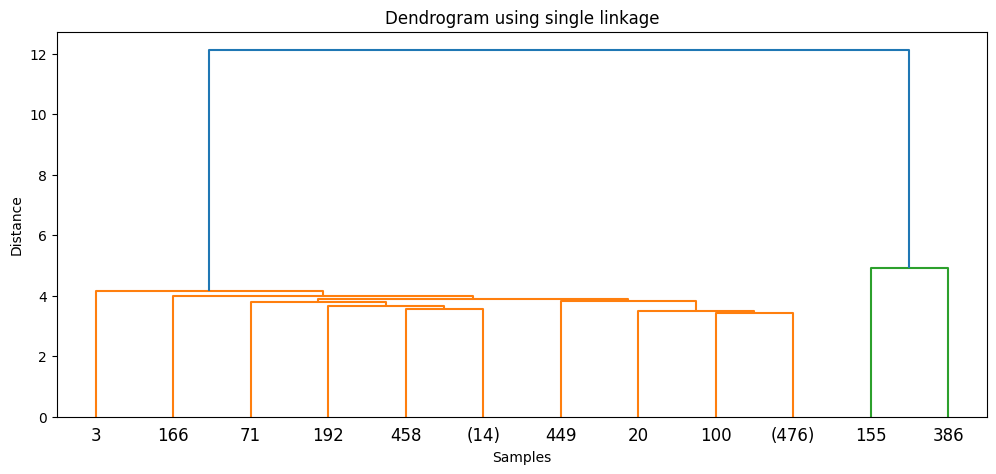

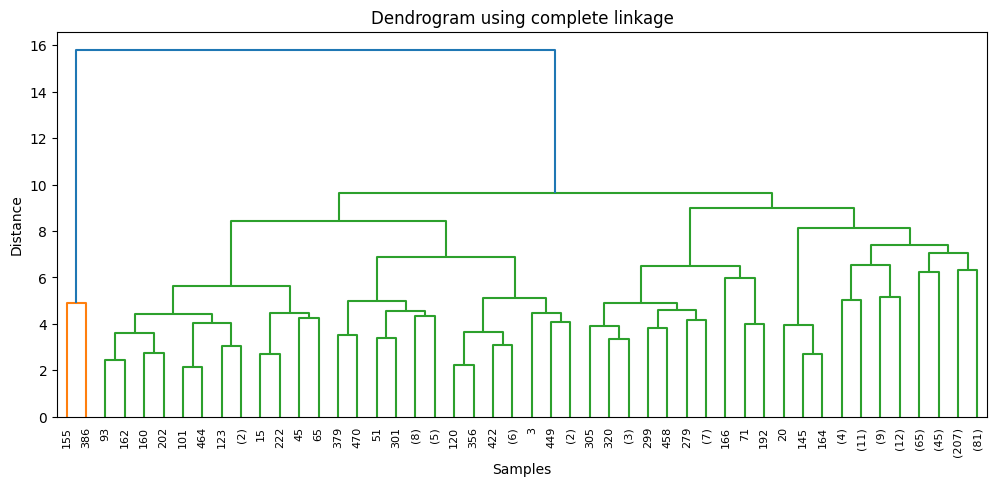

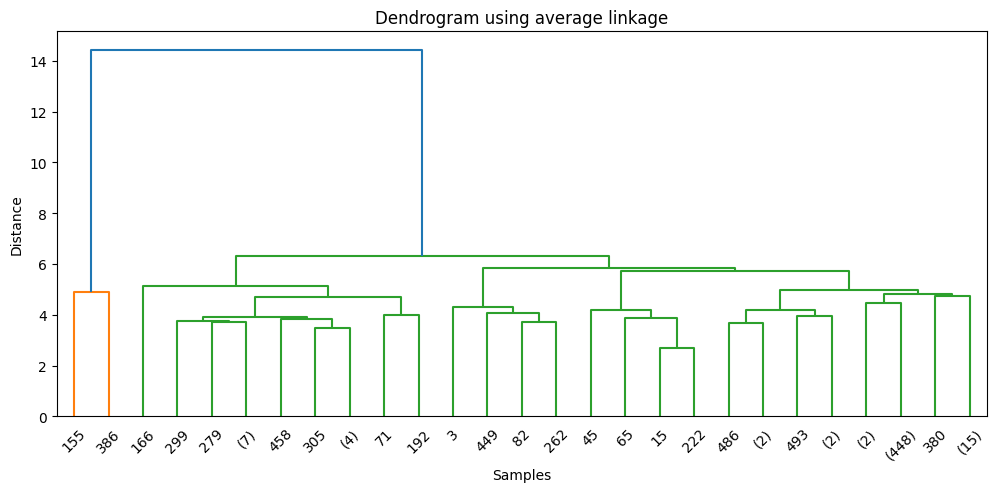

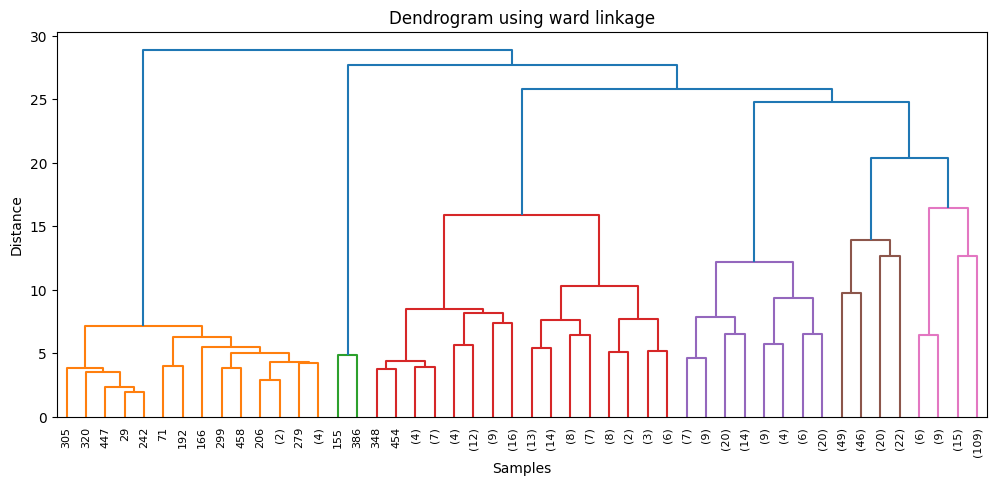

In [ ]:
# plot dendrogram
methods = ["single", "complete", "average", "ward"]
# use sample of data to make it clear and faster (500 sample)
subset_n = 500 if X_hier_sample.shape[0] >= 500 else X_hier_sample.shape[0]
X_sub = X_hier_sample[:subset_n]

for m in methods:
    plt.figure(figsize=(12, 5))
    Z = linkage(X_sub, method=m)
    dendrogram(Z, truncate_mode="level", p=6)
    plt.title(f"Dendrogram using {m} linkage")
    plt.xlabel("Samples")
    plt.ylabel("Distance")
    plt.show()

In [ ]:
# Hierarchical model
# Single linkage
agg_single = AgglomerativeClustering(n_clusters=2, linkage='single')
clusters_single = agg_single.fit_predict(X_hier_sample)

# Complete linkage
agg_complete = AgglomerativeClustering(n_clusters=2, linkage='complete')
clusters_complete = agg_complete.fit_predict(X_hier_sample)

# Average linkage
agg_average = AgglomerativeClustering(n_clusters=2, linkage='average')
clusters_average = agg_average.fit_predict(X_hier_sample)

# --- Silhouette for Hierarchical (sampled data) ---
sil_single = silhouette_score(X_hier_sample, clusters_single)
sil_complete = silhouette_score(X_hier_sample, clusters_complete)
sil_average = silhouette_score(X_hier_sample, clusters_average)

print("Silhouette (Hierarchical - single):", sil_single)
print("Silhouette (Hierarchical - complete):", sil_complete)
print("Silhouette (Hierarchical - average):", sil_average)

Silhouette (Hierarchical - single): 0.7073089925191328
Silhouette (Hierarchical - complete): 0.7073089925191328
Silhouette (Hierarchical - average): 0.7073089925191328


In [ ]:
# Compare clusters with true labels
# K-Means vs True Labels (full data)
print("\n=== K-Means vs True Labels ===")
table_km = pd.crosstab(clusters_kmeans, y['income'], rownames=['Cluster'], colnames=['True Label'])
print(table_km)

# Hierarchical vs True Labels (same sample)
y_sample = y.iloc[sample_idx].reset_index(drop=True)

print("\n=== Hierarchical (single) vs True Labels ===")
print(pd.crosstab(clusters_single, y_sample['income']))

print("\n=== Hierarchical (complete) vs True Labels ===")
print(pd.crosstab(clusters_complete, y_sample['income']))

print("\n=== Hierarchical (average) vs True Labels ===")
print(pd.crosstab(clusters_average, y_sample['income']))


=== K-Means vs True Labels ===
True Label  <=50K   >50K
Cluster                 
0           22403   1131
1           14752  10556

=== Hierarchical (single) vs True Labels ===
income  <=50K  >50K
row_0              
0        1529   463
1           0     8

=== Hierarchical (complete) vs True Labels ===
income  <=50K  >50K
row_0              
0        1529   463
1           0     8

=== Hierarchical (average) vs True Labels ===
income  <=50K  >50K
row_0              
0        1529   463
1           0     8


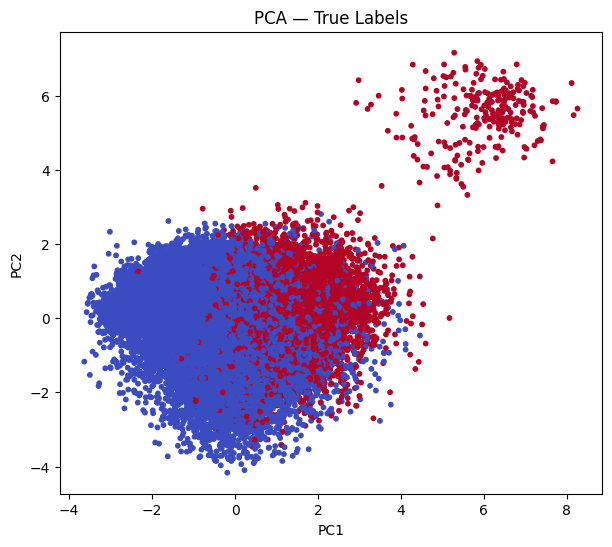

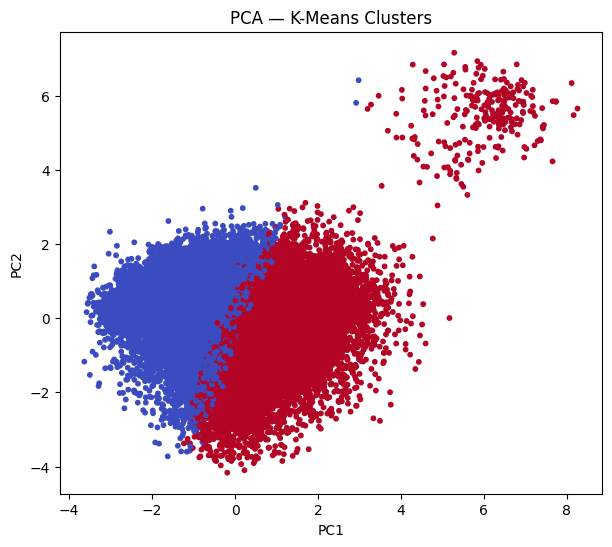

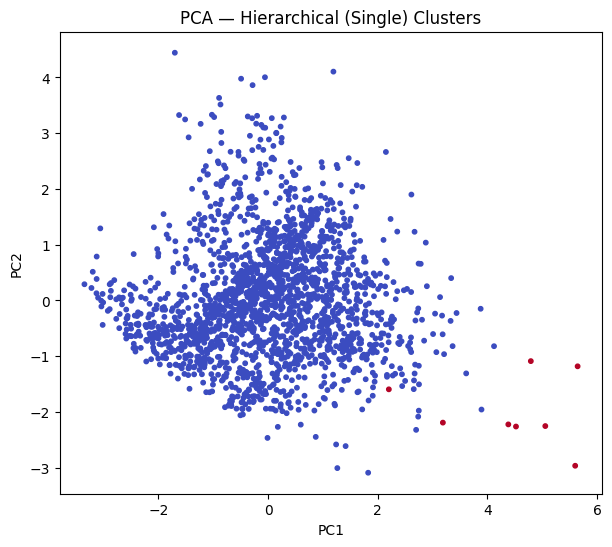

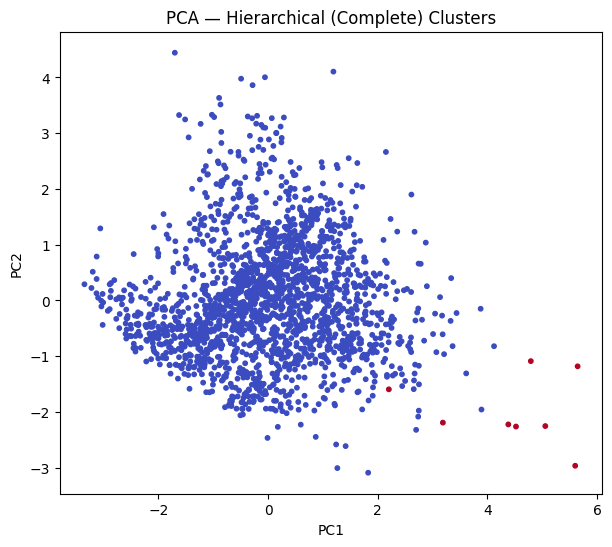

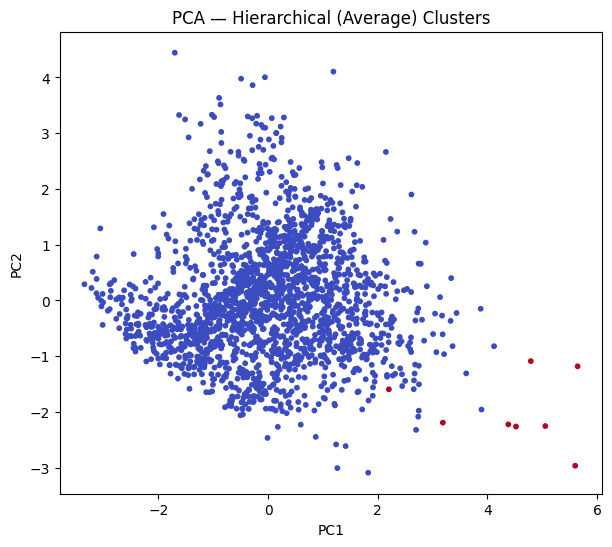

In [ ]:
# plot PCA
pca = PCA(n_components=2)
X_pca_full = pca.fit_transform(X_proc_all)

# Map income labels to numerical values for coloring
y_numeric = y['income'].map({'<=50K': 0, '>50K': 1})

# True Labels
plt.figure(figsize=(7,6))
plt.scatter(X_pca_full[:,0], X_pca_full[:,1], c=y_numeric, cmap='coolwarm', s=10)
plt.title("PCA — True Labels")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# K-Means Clusters
plt.figure(figsize=(7,6))
plt.scatter(X_pca_full[:,0], X_pca_full[:,1], c=clusters_kmeans, cmap='coolwarm', s=10)
plt.title("PCA — K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Apply PCA on the sample
X_pca_sample = pca.fit_transform(X_hier_sample)

# Hierarchical (Single) Clusters
plt.figure(figsize=(7,6))
plt.scatter(X_pca_sample[:,0], X_pca_sample[:,1], c=clusters_single, cmap='coolwarm', s=10)
plt.title("PCA — Hierarchical (Single) Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Hierarchical (Complete) Clusters
plt.figure(figsize=(7,6))
plt.scatter(X_pca_sample[:,0], X_pca_sample[:,1], c=clusters_complete, cmap='coolwarm', s=10)
plt.title("PCA — Hierarchical (Complete) Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Hierarchical (Average) Clusters
plt.figure(figsize=(7,6))
plt.scatter(X_pca_sample[:,0], X_pca_sample[:,1], c=clusters_average, cmap='coolwarm', s=10)
plt.title("PCA — Hierarchical (Average) Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Q4.

1.

SVM provided good performance, although not very excellent, but it was still better than the performance of clustering. The reason is that SVM is a supervised method, meaning it has labels to learn from, and the RBF kernel is capable of learning complex nonlinear patterns. However, the dataset is very large and complicated, which caused a reduction in the results. Despite that, the model was able to learn and classify the two classes well, especially the RBF model, which was better than the linear one. Both models gave good results, but with some weakness. As for K-Means from the clustering methods, it gave me a very low Silhouette score, which means the two clusters are overlapping and the separation between them is weak. But on the other hand, when comparing the results with the true labels and looking at the PCA plot, it became clear that the model was able to classify some groups of the data correctly. Still, the overall performance was not very high because of the overlap, the large size of the data, and its complexity. Therefore, the clusters are mixed and overlapping, and it was not able to separate them completely, but only partially. Finally, Hierarchical Clustering gave a high Silhouette score, meaning that the internal clustering seems good, but in the comparison table with the true labels and in the PCA plot, it shows that the model placed most of the data in one cluster and the outliers in another cluster that contains only a few >50K. This result is not logical and does not match the true labels or the target. Both clustering models are not suitable for large and complex data like this. SVM provided the best performance whether linear or nonlinear, then K-Means which achieved partial separation, and finally Hierarchical, which did not achieve the goal of separation.

2.
The best method was SVM, especially the nonlinear one, because it learns from the labels and searches for the best hyperplane values to separate the classes and reduce error. During training, it sees and learns the best separation method, especially with large and complex data like this. The RBF kernel can understand nonlinear patterns, which gives better results.


3.
All models, whether supervised or unsupervised, need scaling because they all depend on distances or dot products. If there are features with large scales or features that dominate the data, the models will give very poor results. Therefore, scaling helped provide balanced results and a stable hyperplane in SVM, and meaningful distance calculations in clustering. As for encoding, I used one-hot encoding to convert the categorical features into numerical representations that are accepted by SVM and K-Means, because without encoding the models would not work or would give incorrect and poor results. Also, taking a balanced sample for SVM must have given better and less biased results even if they were not very high.


4.
I recommend using SVM because it gave the best classification results, especially the RBF model, which was able to detect some nonlinear patterns in the data and gave good results even though the data is complex and large. Then K-Means, which was able to understand and partially separate the data, but it cannot be fully relied on because the data is not suitable for it and is very large. Finally, Hierarchical Clustering can be used for exploration but not for classification or prediction. However, if there were better models to handle the data, they would be better, because even SVM did not give extremely excellent results but rather good ones.
